# Stage 4a — Generalised LoRA Fine-Tuning
## Model: `google/gemma-3-27b-it` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1

### Gemma-3-27B — the largest model, requires special handling

| Property | Value |
|---|---|
| **HF token** | Required |
| **dtype** | `bfloat16` |
| **Train batch** | 2 (27B model — maximum safe on A100) |
| **Gradient accumulation** | 8 (effective batch = 16) |
| **Eval batch** | 8 |
| **PEFT layers** | 329 (most of all 5 models) |
| **gradient_checkpointing** | True (required for memory) |
| **enable_input_require_grads()** | Before prepare_model_for_kbit_training() |
| **attn_implementation** | 'eager' (required — flash attention incompatible) |
| **DynamicCache fix** | CustomTrainer.prediction_step override (Gemma-3 outputs include DynamicCache) |
| **Eff. rank** | 2596.19 — constant across all ranks and stages |
| **Test inference batch** | 2 (avoid OOM after long training runs) |

### Cross-stage reference

| Stage | r=4 | r=8 | r=16 | r=32 | Best | Eff.Rank |
|---|---|---|---|---|---|---|
| S2 (additive) | 0.8502 | 0.8647 | 0.8764 | 0.8820 | r=32 | 2596.19 ✓ |
| S3 (multiplicative) | 0.8987 | 0.8984 | **0.8988** | 0.8948 | r=16 | 2595.71–2596.18 ✓ |

### Expected training time

~8–10 hrs per run × 4 ranks = **~32–40 hrs total**. Run overnight or split Step 12 + Step 13.

### Stage 4 CB1 scorecard (4 of 5 complete)

| Model | S4 best | Best r | vs S2 | vs S3 |
|---|---|---|---|---|
| Llama-3B | 0.8981 | r=16 | ✓ +0.0023 | ✓ +0.0042 |
| Mistral-7B | 0.8975 | r=16 | ✓ +0.0026 | ≈ −0.0009 |
| Gemma-2-9B ★ | **0.9082** | r=4 | ✓ +0.0072 | ✓ +0.0138 |
| Phi-4 | 0.8986 | r=8 | ✓ +0.0314 | ✓ +0.0068 |


---
## Step 1: Install

**After running: Runtime → Restart Runtime, then Step 2 onwards.**

In [1]:
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print("\n" + "=" * 60)
print("  ACTION REQUIRED: Restart runtime, then run from Step 2.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Import Libraries

**Gemma-3-27B requires HF token.**

In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
from types import SimpleNamespace
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

def load_hf_token():
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found.")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()
drive.mount('/content/drive')
print("✓ Google Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Gemma-3-27B:** batch=2, grad_accum=8, eval_batch=8.

In [2]:
MODEL_NAME   = "google/gemma-3-27b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]

NUM_EPOCHS            = 1
LEARNING_RATE         = 2e-4
TRAIN_BATCH_SIZE      = 2       # 27B model — confirmed safe at 54/80 GB on A100
GRAD_ACCUMULATION     = 8       # Effective batch = 2 × 8 = 16
EVAL_BATCH_SIZE       = 8
TEST_INFERENCE_BATCH  = 2       # Avoid OOM at inference after long training
WEIGHT_DECAY          = 0.01
EVAL_STEPS            = 200
LOGGING_STEPS         = 50
OUTPUT_DIR            = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma3_27B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying': 0, 'gender': 1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model     : {MODEL_NAME}  (27B params)")
print(f"  Formula   : Wf = W(I + UV) + AB")
print(f"  Batch     : {TRAIN_BATCH_SIZE} × grad_accum {GRAD_ACCUMULATION} = eff. {TRAIN_BATCH_SIZE*GRAD_ACCUMULATION}  (batch=1 for 27B memory safety)")
print(f"  Eval batch: {EVAL_BATCH_SIZE} | Test inference: {TEST_INFERENCE_BATCH}")
print(f"  Rank sweep: {RANK_SWEEP}")
print()
print("  S2: r=4: 0.8502 | r=8: 0.8647 | r=16: 0.8764 | r=32: 0.8820★  ↑")
print("  S3: r=4: 0.8987 | r=8: 0.8984 | r=16: 0.8988★| r=32: 0.8948  (flat)")
print("  Eff.Rank: 2596.19 — constant")


✓ Configuration loaded.
  Model     : google/gemma-3-27b-it  (27B params)
  Formula   : Wf = W(I + UV) + AB
  Batch     : 2 × grad_accum 8 = eff. 16  (batch=1 for 27B memory safety)
  Eval batch: 8 | Test inference: 2
  Rank sweep: [4, 8, 32]

  S2: r=4: 0.8502 | r=8: 0.8647 | r=16: 0.8764 | r=32: 0.8820★  ↑
  S3: r=4: 0.8987 | r=8: 0.8984 | r=16: 0.8988★| r=32: 0.8948  (flat)
  Eff.Rank: 2596.19 — constant


---
## Step 4: Text Preprocessing

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text
print("✓ Preprocessing function defined.")


✓ Preprocessing function defined.


---
## Step 5: Load and Clean CB1

In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw: {len(df):,}")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] After corrupt removal: {len(df):,}")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,}")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting = text_label_counts[text_label_counts > 1].index
df = df[~df['text'].isin(conflicting)].reset_index(drop=True)
print(f"[5] After conflict removal: {len(df):,}")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] After dedup: {len(df):,}")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Final: {len(df):,}")
assert len(set(df['label'].unique()) - set(LABEL_MAPPING.keys())) == 0
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw: 47,692
[3] After corrupt removal: 47,692
[4] After preprocessing: 46,942
[5] After conflict removal: 43,692
[6] After dedup: 43,334
[7] Final: 43,334
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)


---
## Step 6: Stratified Split

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"[1] Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"[2] Near-duplicate check...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]
leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())
print(f"    Found {len(leaked_indices)} near-duplicates")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
assert len(set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())) == 0
print("    ✓ No leakage.")
train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


[1] Train+Val: 32,500 | Test: 10,834
[2] Near-duplicate check...
    Found 504 near-duplicates
    ✓ No leakage.
[3] Train: 29,703 | Val: 3,301 | Test: 10,330


---
## Step 7: Class Weights

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts()
    total = len(df); n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights:")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm
print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank

Gemma-3-27B reference: 2596.19 (perfectly constant).

In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0
    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer': continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B
            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)
            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)
            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue
            if W.shape[0] == module.m and W.shape[1] == module.n: pass
            elif W.shape[0] == module.n and W.shape[1] == module.m: W = W.T.contiguous()
            else:
                if skipped == 0: print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue
            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception:
            skipped += 1; continue
    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    if not full_ranks: print("  ⚠ No GeneralisedLoRALayer found")
    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }
print("✓ calculate_effective_rank_generalised() defined.")


✓ calculate_effective_rank_generalised() defined.


---
## Step 9: Evaluation Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Normalised\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc}

def make_predictions(model, df_test, tokenizer, batch_size=None):
    if batch_size is None:
        batch_size = TEST_INFERENCE_BATCH   # 2 for Gemma-3-27B — avoids OOM
    model.eval(); all_preds = []
    texts = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(next(model.parameters()).device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy(); df_out['predictions'] = all_preds
    return df_out

print("✓ Evaluation functions defined.")
print(f"  Test inference batch: {TEST_INFERENCE_BATCH}  (Gemma-3-27B — avoid OOM)")


✓ Evaluation functions defined.
  Test inference batch: 2  (Gemma-3-27B — avoid OOM)


---
## Step 10: Stability System + Custom Trainer (Gemma-3-27B DynamicCache fix)

**Gemma-3-27B specific:** `prediction_step` override in CustomTrainer.  
Gemma-3 model outputs include `DynamicCache` objects that `_pad_across_processes` cannot handle.  
The override extracts `(loss, logits, labels)` manually, bypassing the padding step.


In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a)); report[f'val_{m}_range'] = float(a.max()-a.min())
                report[f'val_{m}_best'] = float(a.max()); report[f'val_{m}_final'] = float(a[-1])
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1v = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
                mu, sd = float(np.mean(f1v)), float(np.std(f1v))
                ax2.axhline(mu, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps, [mu-sd]*len(self.val_steps), [mu+sd]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={sd:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen')
            if ax2r and 'mcc' in self.val_metrics:
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange')
            l1, lb1 = ax2.get_legend_handles_labels()
            l2, lb2 = (ax2r.get_legend_handles_labels() if ax2r else ([], []))
            ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"✓ Saved → {save_path}")
        plt.show()


class CustomTrainerGemma27B(Trainer):
    """
    Trainer with:
    1. Class-weighted cross-entropy loss
    2. DynamicCache fix for Gemma-3-27B — prediction_step override

    Gemma-3's model outputs include DynamicCache objects that
    _pad_across_processes cannot serialise. The override extracts
    (loss, logits, labels) manually, bypassing the problematic padding.
    """
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        """
        Override to avoid _pad_across_processes TypeError with DynamicCache.
        Manually computes loss and extracts logits/labels.
        """
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            labels = inputs.get('labels')
            outputs = model(**inputs)
            logits = outputs.logits

            loss = None
            if labels is not None:
                loss_fn = nn.CrossEntropyLoss(
                    weight=self.class_weights.to(logits.device)
                ) if self.class_weights is not None else nn.CrossEntropyLoss()
                loss = loss_fn(logits, labels)

        return (loss, logits, labels)


print("✓ StabilityCallback defined.")
print("✓ CustomTrainerGemma27B defined (DynamicCache fix + class weights).")


✓ StabilityCallback defined.
✓ CustomTrainerGemma27B defined (DynamicCache fix + class weights).


---
## Step 11: Generalised LoRA Adapter + Training Function

**Gemma-3-27B specific handling:**
- `enable_input_require_grads()` before `prepare_model_for_kbit_training()`
- `attn_implementation='eager'` in `from_pretrained()`
- `gradient_checkpointing=True` in TrainingArguments
- `gradient_accumulation_steps=8` (effective batch = 16)
- Uses `CustomTrainerGemma27B` (DynamicCache fix)
- Test inference at `batch_size=2` (avoid OOM)


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Gemma3ForClassification — CausalLM + classification head wrapper
# ════════════════════════════════════════════════════════════════════════════
# Gemma3Config is NOT supported by AutoModelForSequenceClassification in
# transformers<4.52. This wrapper loads AutoModelForCausalLM and adds a
# Linear classification head (same approach as Stage 3).
#
# Memory fix: uses output_hidden_states=True with batch_size=1 (Step 3).
# The transformer bypass approach (calling model.model.model directly)
# does NOT work because it skips the GeneralisedLoRALayer adapters.

class Gemma3ForClassification(nn.Module):
    """
    Wrapper: AutoModelForCausalLM + Linear(hidden_size, num_labels).
    Pooling: last non-padding token hidden state -> score head -> logits.
    """
    def __init__(self, causal_model, num_labels):
        super().__init__()
        self.model = causal_model
        self.num_labels = num_labels
        self.config = causal_model.config
        self.config.num_labels = num_labels
        _dev = next(causal_model.parameters()).device
        _dtype = next(causal_model.parameters()).dtype
        # Gemma-3 is multimodal — hidden_size is in text_config
        if hasattr(causal_model.config, 'hidden_size'):
            hidden_size = causal_model.config.hidden_size
        else:
            hidden_size = causal_model.config.text_config.hidden_size
        self.score = nn.Linear(hidden_size, num_labels, bias=False)
        self.score = self.score.to(device=_dev, dtype=_dtype)
        nn.init.normal_(self.score.weight, std=0.01)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        # MUST use self.model() with output_hidden_states=True — NOT the bare transformer.
        # Calling the transformer directly skips GeneralisedLoRALayer adapters.
        # Memory managed via batch_size=1 in TrainingArguments (Step 3).
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        hidden = outputs.hidden_states[-1]  # last layer hidden state

        # Pool: last non-padding token
        if attention_mask is not None:
            seq_lens = attention_mask.sum(dim=1).long() - 1
        else:
            seq_lens = torch.full(
                (input_ids.shape[0],), input_ids.shape[1] - 1,
                device=input_ids.device, dtype=torch.long)
        batch_idx = torch.arange(hidden.shape[0], device=hidden.device)
        pooled = hidden[batch_idx, seq_lens]
        logits = self.score(pooled.to(self.score.weight.dtype)).float()

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
        return SimpleNamespace(logits=logits, loss=loss)

    @property
    def device(self):
        return next(self.parameters()).device

    def gradient_checkpointing_enable(self, *args, **kwargs):
        self.model.gradient_checkpointing_enable(*args, **kwargs)


# ════════════════════════════════════════════════════════════════════════════
# GeneralisedLoRALayer — Wf = W(I + UV) + AB
# ════════════════════════════════════════════════════════════════════════════

class GeneralisedLoRALayer(nn.Module):
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank
        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")
        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device
        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))
        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)
        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)
        lora_vx = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)
        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T
        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())
    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        gen_layer = GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1
    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora(train_df, val_df, test_df, lora_rank, run_label=''):
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model: {MODEL_NAME}  |  Rank: {lora_rank}  |  Scaling: 1.0')
    print(f'  Batch: {TRAIN_BATCH_SIZE} × accum {GRAD_ACCUMULATION} = eff. {TRAIN_BATCH_SIZE*GRAD_ACCUMULATION}')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for s in [train_m, val_m, test_m]:
        s['label'] = s['label'].map(LABEL_MAPPING)
        assert s['label'].notnull().all()
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    # Gemma3Config not supported by AutoModelForSequenceClassification.
    # Use AutoModelForCausalLM + Gemma3ForClassification wrapper.
    print('[3] Loading model (4-bit NF4 QLoRA — Gemma-3-27B via CausalLM wrapper)...')
    lora_config_causal = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='CAUSAL_LM')

    causal_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=quant_config,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN,
        attn_implementation='eager',
    )
    causal_model.config.pad_token_id = tokenizer.pad_token_id
    causal_model.config.use_cache = False

    causal_model.enable_input_require_grads()
    causal_model = prepare_model_for_kbit_training(causal_model)
    causal_model = get_peft_model(causal_model, lora_config_causal)
    print('   PEFT shell registered (CausalLM).')

    print('[4] Injecting GeneralisedLoRALayer...')
    causal_model, _, _ = apply_generalised_lora_over_peft(
        causal_model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)

    # Wrap with classification head
    model = Gemma3ForClassification(causal_model, NUM_LABELS)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'   Gemma3ForClassification wrapper applied.')
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUMULATION,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        load_best_model_at_end=False,
        gradient_checkpointing=True,
        fp16=False, bf16=True,
        report_to='none', remove_unused_columns=False,
        dataloader_pin_memory=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainerGemma27B(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training (Wf = W(I+UV)+AB, r={lora_rank}, batch={TRAIN_BATCH_SIZE}×{GRAD_ACCUMULATION})...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Gemma-3-27B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    print('\n[6] Computing effective rank...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2/S3: 2596.19')
    print(f'   Eff.Rank UV: {rank_info["avg_eff_rank_UV"]:.2f} | AB: {rank_info["avg_eff_rank_AB"]:.2f}')
    print(f'   Layers: {rank_info["layer_count"]}')

    print(f'\n[7] Evaluating on test set (batch={TEST_INFERENCE_BATCH})...')
    test_preds = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(), f'Stage4_CB1_{label}')

    row = {
        'model': 'Gemma-3-27B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ Gemma3ForClassification defined (CausalLM + score head).")
print("✓ GeneralisedLoRALayer, apply_generalised_lora_over_peft(), run_generalised_lora() defined.")
print("  Gemma-3-27B: batch=1×16 | gradient_checkpointing | attn=eager | CausalLM wrapper")

✓ Gemma3ForClassification defined (CausalLM + score head).
✓ GeneralisedLoRALayer, apply_generalised_lora_over_peft(), run_generalised_lora() defined.
  Gemma-3-27B: batch=1×16 | gradient_checkpointing | attn=eager | CausalLM wrapper


---
## Step 12: Execute — r=16 (default)

**Expected time:** ~8–10 hrs on A100  
**S2 r=16:** F1=0.8764 | **S3 r=16:** F1=0.8988 ★


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model: google/gemma-3-27b-it  |  Rank: 16  |  Scaling: 1.0
  Batch: 2 × accum 8 = eff. 16

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

   PEFT shell registered (CausalLM).
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 329 PEFT LoraLayers with GeneralisedLoRALayer
   Gemma3ForClassification wrapper applied.
   Trainable: 79,650,304 | Total: 14,507,340,912 | 0.5490%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV)+AB, r=16, batch=2×8)...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,7.373200,0.771519,0.719176,0.698790,0.663615
400,5.332300,0.864088,0.745835,0.662358,0.704089
600,4.690200,0.607856,0.777946,0.702519,0.749862
800,4.158300,0.507343,0.836716,0.816261,0.803893
1000,3.961600,0.566545,0.781278,0.725445,0.759929
1200,3.673300,0.441418,0.837019,0.811066,0.807597
1400,3.170400,0.391814,0.868828,0.857634,0.843121
1600,2.831400,0.379263,0.871251,0.856963,0.846165
1800,2.726100,0.367145,0.866707,0.849632,0.842039


   Time: 29416s (8.17 hrs)
   Stability: 0.3140
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma3_27B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


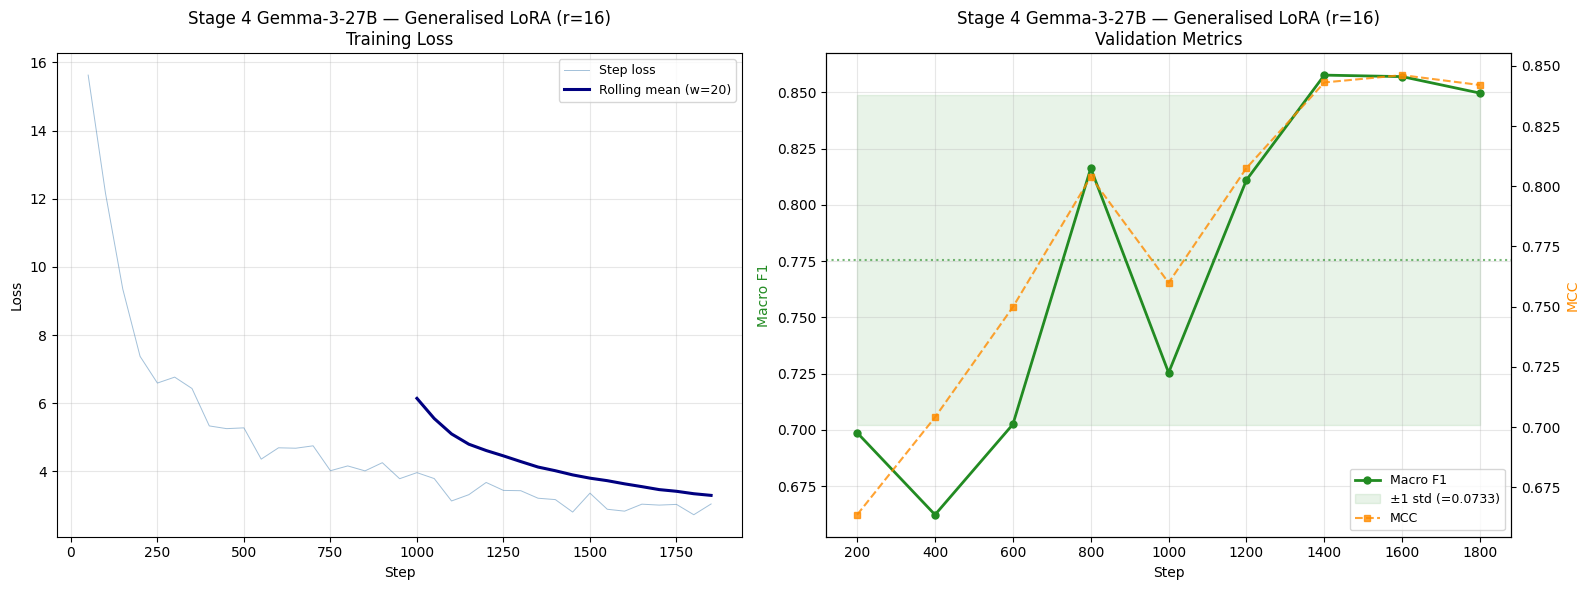


[6] Computing effective rank...
   Eff.Rank Wf: 2596.18  ← S2/S3: 2596.19
   Eff.Rank UV: 12.06 | AB: 12.06
   Layers: 329

[7] Evaluating on test set (batch=2)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8651
  Macro F1          : 0.8466  ← PRIMARY
  Weighted F1       : 0.8641
  Balanced Accuracy : 0.8488
  MCC               : 0.8390  ← SECONDARY

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7306    0.5428    0.6229      1424
             gender     0.8919    0.8579    0.8746      1788
           religion     0.9417    0.9594    0.9505      1971
          ethnicity     0.9632    0.9691    0.9662      1812
                age     0.9718    0.9549    0.9633      1950
other_cyberbullying     0.6205    0.8087    0.7022      1385

           accuracy         

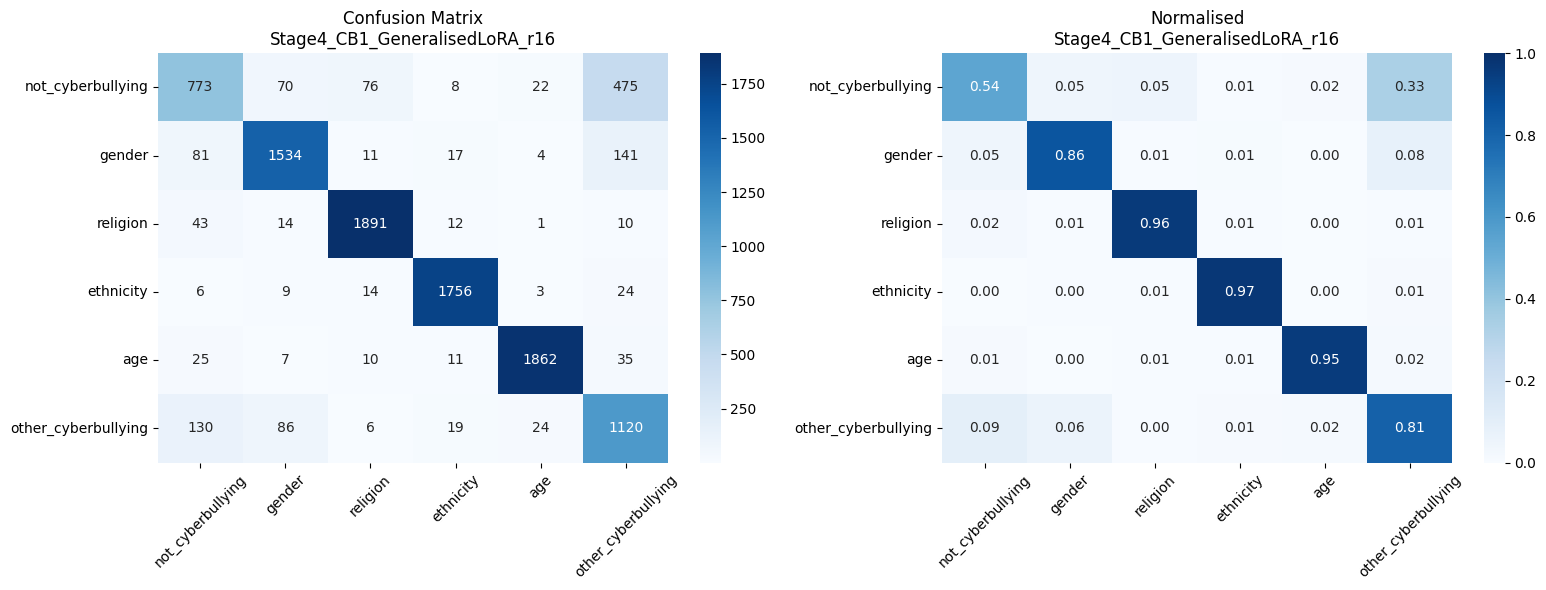


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma3_27B/GeneralisedLoRA_r16

═════════════════════════════════════════════════════════════════
  STAGE 4 RESULTS — Gemma-3-27B r=16
═════════════════════════════════════════════════════════════════
  Macro F1          : 0.8466   ← PRIMARY
  MCC               : 0.8390
  Eff. rank (Wf)    : 2596.18  ← S2/S3: 2596.19
  Stability         : 0.3140
  Time              : 8.17 hrs
  Δ vs S2 r=16      : -0.0298
  Δ vs S3 r=16      : -0.0522

  → Step 13 sweeps r ∈ {4, 8, 32}.


In [11]:
results_r16 = run_generalised_lora(
    train_df=train_df, val_df=val_df, test_df=test_df,
    lora_rank=16, run_label='GeneralisedLoRA_r16')

print('\n' + '═'*65)
print('  STAGE 4 RESULTS — Gemma-3-27B r=16')
print('═'*65)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC               : {results_r16["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {results_r16["avg_eff_rank_Wf"]:.2f}  ← S2/S3: 2596.19')
print(f'  Stability         : {results_r16["stability_score"]:.4f}')
print(f'  Time              : {results_r16["train_runtime_s"]/3600:.2f} hrs')
print(f'  Δ vs S2 r=16      : {results_r16["macro_f1"] - 0.8764:+.4f}')
print(f'  Δ vs S3 r=16      : {results_r16["macro_f1"] - 0.8988:+.4f}')
print('\n  → Step 13 sweeps r ∈ {4, 8, 32}.')


---
## Step 13: Rank Sweep — r ∈ {4, 8, 32}

r=16 from Step 12. This is the longest step (~24–30 hrs total).

In [12]:
all_rank_results = {16: results_r16}

for rank in RANK_SWEEP:
    print(f'\n{"─"*55}\n  Rank sweep: r={rank}\n{"─"*55}')
    result = run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=rank, run_label=f'GeneralisedLoRA_r{rank}')
    all_rank_results[rank] = result

print(f'\n{"═"*105}')
print('STAGE 4a CB1 GEMMA-3-27B — 4-RANK SUMMARY TABLE')
print(f'{"═"*105}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>11} | {"Eff.Rank UV":>11} | {"Eff.Rank AB":>11} | '
      f'{"Stability":>9} | {"Time(h)":>8} | Trend')
print(f'{"─"*105}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    print(f'{r:>4} | {res["trainable_params"]:>12,} | {res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
          f'{res["avg_eff_rank_Wf"]:>11.2f} | {res["avg_eff_rank_UV"]:>11.2f} | '
          f'{res["avg_eff_rank_AB"]:>11.2f} | {res["stability_score"]:>9.4f} | '
          f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}')
    prev_f1 = res['macro_f1']

print()
print('  S2: r=4: 0.8502 | r=8: 0.8647 | r=16: 0.8764 | r=32: 0.8820★')
print('  S3: r=4: 0.8987 | r=8: 0.8984 | r=16: 0.8988★| r=32: 0.8948')

eff_ranks = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks if all_rank_results[r]['avg_eff_rank_Wf'] > 0]
if eff_ranks:
    eff_range = max(eff_ranks) - min(eff_ranks)
    print(f'\n  Eff. rank Wf range: {eff_range:.2f}  (S2/S3: ~0.47)')
    if eff_range < 1.0: print('  ✓ Perfectly constant')
    else: print('  ⚠ Varies')

summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Gemma-3-27B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': r, 'trainable_params': res['trainable_params'],
        'macro_f1': res['macro_f1'], 'mcc': res['mcc'],
        'accuracy': res['accuracy'], 'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf': res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': res['avg_eff_rank_UV'], 'avg_eff_rank_AB': res['avg_eff_rank_AB'],
        'stability_score': res['stability_score'], 'train_runtime_s': res['train_runtime_s'],
    })
summary_path = os.path.join(OUTPUT_DIR, 'stage4a_cb1_gemma3_27b_rank_sweep_FINAL.csv')
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
print(f'\n✓ Final results saved → {summary_path}')



───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model: google/gemma-3-27b-it  |  Rank: 4  |  Scaling: 1.0
  Batch: 2 × accum 8 = eff. 16

[1] Loading tokenizer...
   Vocab: 262,144
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA — Gemma-3-27B via CausalLM wrapper)...


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

---
## Step 14: Final Summary — Stage 4 CB1 Complete (All 5 Models)

In [ ]:
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA | Gemma-3-27B-IT')
print('  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class')
print('  *** FINAL MODEL — STAGE 4 CB1 COMPLETE ***')
print('═'*70)

best_r = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best = all_rank_results[best_r]

print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1          : {best["macro_f1"]:.4f}')
print(f'  MCC               : {best["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {best["avg_eff_rank_Wf"]:.2f}')
print(f'  Stability         : {best["stability_score"]:.4f}')
print(f'  Time              : {best["train_runtime_s"]/3600:.2f} hrs')

print(f'\n── CROSS-STAGE (Gemma-3-27B, best each stage) ──')
print(f'  Stage 2 (r=32): F1=0.8820 | MCC=0.8726')
print(f'  Stage 3 (r=16): F1=0.8988 | MCC=0.8911')
print(f'  Stage 4 (r={best_r:>2}): F1={best["macro_f1"]:.4f} | MCC={best["mcc"]:.4f}')
print(f'  Δ vs S2: {best["macro_f1"] - 0.8820:+.4f}  |  Δ vs S3: {best["macro_f1"] - 0.8988:+.4f}')

print(f'\n══════════════════════════════════════════════════════════════════')
print(f'  STAGE 4 CB1 — COMPLETE SCORECARD (ALL 5 MODELS)')
print(f'══════════════════════════════════════════════════════════════════')
print(f'  Gemma-2-9B ★  : F1=0.9082 (r=4)   | vs S2: +0.0072 | vs S3: +0.0138')
print(f'  Phi-4         : F1=0.8986 (r=8)   | vs S2: +0.0314 | vs S3: +0.0068')
print(f'  Llama-3B      : F1=0.8981 (r=16)  | vs S2: +0.0023 | vs S3: +0.0042')
print(f'  Mistral-7B    : F1=0.8975 (r=16)  | vs S2: +0.0026 | vs S3: -0.0009')
print(f'  Gemma-3-27B   : F1={best["macro_f1"]:.4f} (r={best_r})   | vs S2: {best["macro_f1"]-0.8820:+.4f} | vs S3: {best["macro_f1"]-0.8988:+.4f}')
print()
print(f'  → Next: Stage 4b — CB2 (binary classification)')
